# LLM for Text Classification

## Overview

This project evaluates the capability of using a Large Language Model (LLM)—either via API or running locally—to classify the origin of a given text.

## Implemented Approaches

### 1. Zero-Shot Classification

Relies entirely on the model’s inherent capabilities to classify text without providing any prior examples.

* No training examples are included in the prompt
* The model infers the classification based on its pre-trained knowledge

### 2. Few-Shot Classification

Enhances classification performance by providing example inputs.

Two variations were implemented:

#### a. Static Examples

* Uses a predefined set of manually selected examples
* Examples are fixed and reused across all predictions

#### b. RAG-Based Examples (Retrieval-Augmented Generation)

* Dynamically retrieves relevant examples based on the input text
* Improves contextual relevance and classification accuracy

### 3. Fine-Tuning (Local Model)

* Involves training a local LLM on a labeled dataset
* Aims to specialize the model for the classification task
* Requires additional computational resources and dataset preparation

---

## Setup

### Requirements

The notebook relies on the following libraries:

* `pandas` – data manipulation and inspection
* `matplotlib` – basic data visualization
* `openai` – API-based LLM interaction (via OpenRouter)

### Steps

1. Load the dataset
2. Import required dependencies
3. Configure API access (if using remote models)

---

## Artifacts and Checkpoints

* Precomputed checkpoints for the fine-tuned model and RAG embeddings are provided
* The full fine-tuned model is **not included** and must be generated before execution
* Training the model from scratch can be time-consuming and resource-intensive


In [1]:
# imports
import os
import json
import random
import time

#pip install openai datasets python-dotenv
from typing import List, Dict, Optional
from dotenv import load_dotenv  
from openai import OpenAI

In [2]:
# load environment variables, API key for OpenRouter

load_dotenv(".env")  # Load environment variables from a .env file if present, this file contains the OPENROUTER_API_KEY 

# Using OpenRouter to access other models, including Mistral and Groq, with a single API key, and other free models to use
OPEN_ROUTER_API_KEY = os.getenv("OPEN_ROUTER_API_KEY")

client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=OPEN_ROUTER_API_KEY,
)

print("OpenRouter key loaded:", bool(OPEN_ROUTER_API_KEY))

OpenRouter key loaded: True


In [3]:
# list of LLM models used for selection and cost analysis

LLM_MODELS = {
    #"deepseek/deepseek-r1-distill-qwen-32b": {
    #    "input": 0.29 / 1_000,   # $ per 1K input tokens 
    #    "output": 0.289 / 1_000,   # $ per 1K output tokens
    #},
    # "deepseek/deepseek-r1-0528": {
    #    "input": 0.506 / 1_000,  
    #    "output": 2.31 / 1_000,  
    #},
    #"deepseek/deepseek-chat-v3-0324": {
    #    "input": 0.252 / 1_000,  
    #    "output": 0.950 / 1_000,  
    #},
    "deepseek/deepseek-chat": {
        "input": 0.32 / 1_000,  
        "output": 0.89 / 1_000,  
    },
    "openai/gpt-5.4-mini": {
        "input": 0.373 / 1_000,  
        "output": 4.50 / 1_000,   
    },
     "openai/gpt-5.4-nano": {
        "input": 0.20 / 1_000,  
        "output": 1.25 / 1_000,   
    },
     "google/gemini-3.1-flash-lite-preview": {
        "input": 0.18 / 1_000,  
        "output": 1.50 / 1_000,   
    },
    "google/gemini-3-flash-preview": {
        "input": 0.329 / 1_000,  
        "output": 3.00 / 1_000,   
    },
     "google/gemini-2.5-flash-lite": {
        "input": 0.067 / 1_000,  
        "output": 0.399 / 1_000,   
    },
     "anthropic/claude-haiku-4.5": {
        "input": 0.572 / 1_000,  
        "output": 5.0 / 1_000,   
    },
     "anthropic/claude-3.5-haiku": {
        "input": 0.693 / 1_000,  
        "output": 4.0 / 1_000,   
    },
 
     "nvidia/llama-3.3-nemotron-super-49b-v1.5": {
        "input": 0.10 / 1_000,  
        "output": 0.399 / 1_000,  
    },
     "mistralai/mistral-small-3.2-24b-instruct": {
        "input": 0.075 / 1_000,  
        "output": 0.20 / 1_000,  
    },
     "x-ai/grok-3-mini": {
        "input": 0.30 / 1_000,  
        "output": 0.50 / 1_000,  
    },
    # "qwen/qwen3.5-flash-02-23": {
    #    "input": 0.10 / 1_000,  
    #    "output": 0.40 / 1_000,   
    #},
    # "minimax/minimax-m2.5": {
    #    "input": 0.092 / 1_000,  
    #    "output": 1.19 / 1_000,   
    #},
    # "z-ai/glm-4.7-flash": {
    #    "input": 0.066 / 1_000,  
    #    "output": 0.40 / 1_000,   
    #},
        "x-ai/grok-4.1-fast": {
        "input": 0.154 / 1_000,   # $ per 1K input tokens 
        "output": 0.50 / 1_000,   # $ per 1K output tokens
    },
     "mistralai/mistral-nemo": {
        "input": 0.02 / 1_000,  
        "output": 0.04 / 1_000,  
    },
}

#### Main FUNCTIONS AND API CALLS


In [4]:
# functions for data preparation
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42  # Fixed seed value used across split/sampling
random.seed(SEED)
label_map = {'Human':0, 'OpenAI':1, 'Google':2, 'Meta':3, 'Anthropic':4}

def data_preparation():
    # to ensure that the test data will never be used on the LLM training, so we store the inital split in a csv file
    csv_path = 'df_train_test_split.csv'
    
    # Check if preprocessed split already exists
    if os.path.exists(csv_path):
        df_combined = pd.read_csv(csv_path)
        df_train = df_combined[df_combined['split'] == 'train'].drop('split', axis=1)
        df_test = df_combined[df_combined['split'] == 'test'].drop('split', axis=1)
        print("Loaded train/test split from existing CSV")
        return df_train, df_test
    
    # 1. Load and Map Labels
    df = pd.read_csv('df_exportado.csv')
    df['label'] = df['Label'].map(label_map)

    # remove duplicates
    df = df.drop_duplicates(subset=['Text'])

    # 2. Split and Stratify (The 80/20 split)
    df_train, df_test = train_test_split(
        df, test_size=0.2, random_state=SEED, stratify=df['label']
    )

    # 4. Add Readable Names for Display
    reverse_map = {v: k for k, v in label_map.items()}
    df_train["label_name"] = df_train["label"].map(reverse_map)
    df_test["label_name"] = df_test["label"].map(reverse_map)

    # 5. Save split for reproducibility
    df_combined = pd.concat([df_train.assign(split='train'), df_test.assign(split='test')])
    df_combined.to_csv(csv_path, index=False)
    print(f"Saved train/test split to {csv_path}")

    # 6. Show Results
    display(df_train.head())
    print("Train distribution:")
    print(df_train["label_name"].value_counts())

    display(df_test.head())
    print("Test distribution:")
    print(df_test["label_name"].value_counts())

    return df_train, df_test

# generate dataset for the LLM MODEL SELECTION, and cost analysis
df_train, df_test = data_preparation()

Loaded train/test split from existing CSV


In [5]:
# basic functions, run experiments, OPENAI API CALL, and cost estimation

def estimate_cost(model, usage):
    if model not in LLM_MODELS or not usage:
        return None

    input_cost = (usage["prompt_tokens"] / 1000.0) * LLM_MODELS[model]["input"]
    output_cost = (usage["completion_tokens"] / 1000.0) * LLM_MODELS[model]["output"]

    return {
        "input_cost": input_cost,
        "output_cost": output_cost,
        "total_cost": input_cost + output_cost
    }


def normalize_prediction(text):
    # convert a raw model answer into one of the valid labels or None
    if text is None:
        return None

    text = str(text).strip()
    if not text:
        return None

    # exact case-insensitive match first
    for label in label_map.keys():
        if text.lower() == label.lower():
            return label

    # fallback: look for one valid label anywhere in the output
    for label in label_map.keys():
        if label.lower() in text.lower():
            return label

    return None 

def calculate_accuracy(preds, gold):
    correct = sum(p == g for p, g in zip(preds, gold))
    total = len(gold)
    return correct / total if total > 0 else 0

# KEEP System prompt consistent to ensure cached context is used
def CALL_OPENAI_API(model, System_Prompt, Prompt):
    messages = [
        {
            "role": "system", 
            "content": System_Prompt
        },
        {
            "role": "user", 
            "content": Prompt
        }
    ]

    # - use temperature=0 for deterministic behavior
    completion = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0,
    )

    # VALIDATE THE CACHE HIT AND USAGE

    Usage = {
        "prompt_tokens": getattr(completion.usage, "prompt_tokens", None),
        "completion_tokens": getattr(completion.usage, "completion_tokens", None),
        "total_tokens": getattr(completion.usage, "total_tokens", None),
        "cached_tokens": getattr(completion.usage.prompt_tokens_details, "cached_tokens", None)
    }
    
    estimated_cost = estimate_cost(model, Usage)
    if(estimated_cost is not None):
        Usage["cost"] = estimated_cost["total_cost"]
        
    # GET THE COST FROM THE USAGE, if available, otherwise uses estimate_cost function
    extra = getattr(completion.usage, "model_extra", None) or getattr(completion.usage, "extra", {})
    if isinstance(extra, dict) and "cost" in extra:
        Usage["cost"]  = extra["cost"]
    elif hasattr(extra, "cost"):
        Usage["cost"]  = extra.cost

    response = ""
    if hasattr(completion, "choices") and len(completion.choices) > 0:
        choice = completion.choices[0]
        if hasattr(choice, "message"):
            msg = choice.message
            if isinstance(msg, dict):
                response = msg.get("content", "")
            else:
                response = getattr(msg, "content", "") or ""
        elif isinstance(choice, dict):
            response = choice.get("message", {}).get("content", "")

    return response.strip(),  Usage

def run_experiment(
    model,
    dataset_split,
    prompt_builder, # fn that builds the prompt for  example
    support_examples: Optional[List[Dict]] = None, # list of examples to include in the prompt for few-shot
    sleep_seconds=0.0,
    model_call_func=CALL_OPENAI_API
):
    predictions = []
    raw_outputs = []
    usage_details = []

    experiment_cost = 0.0
    prompt = ""
 
    total_rows = len(dataset_split)

    for processed, (idx, example) in enumerate(dataset_split.iterrows(), start=1):
        # - build the prompt
        # - call the API
        # - normalize the answer
        # - store both raw and normalized outputs
        # - handle errors with try/except
        if support_examples is not None:
            system_prompt, prompt = prompt_builder(example, support_examples)
        else:
            system_prompt, prompt = prompt_builder(example)

        raw = ""

        try:
            raw, usage = model_call_func(model, system_prompt, prompt)
            pred = normalize_prediction(raw)
            experiment_cost += usage.get("cost", 0.0)

            rows_left = total_rows - processed
            print(
                f"\t\tExample {idx}: Correct: {pred == example['label_name']},  Predicted: {pred}, Gold: {example['label_name']}, "
                f"Usage: {usage}, cost: {usage.get('cost', 0.0)} | Rows left: {rows_left}"
            )
        except Exception as e:
            raw = f"ERROR: {str(e)}"
            usage = {"cost": 0.0}
            pred = None

            rows_left = total_rows - processed
            print(f"\t\tExample {idx}: ERROR | Rows left: {rows_left}")

        raw_outputs.append(raw)
        predictions.append(pred)
        usage_details.append(usage)

        # optional pause to respect rate limits
        time.sleep(sleep_seconds)

    return predictions, raw_outputs, usage_details, experiment_cost

In [6]:
# these functions help to visualize the results

import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

LABELS = list(label_map.keys())  # ['Human', 'OpenAI', 'Google', 'Meta', 'Anthropic']

def build_confusion_matrix(gold, preds, title, ax):
    cleaned_preds = [p if p is not None else "__none__" for p in preds]

    cm = confusion_matrix(gold, cleaned_preds, labels=LABELS)

    # Per-label F1 scores as x-tick annotations
    f1_per_label = f1_score(gold, cleaned_preds, labels=LABELS, average=None, zero_division=0)
    xtick_labels = [f"{l}\n(F1={f:.2f})" for l, f in zip(LABELS, f1_per_label)]

    # Weighted global F1 and accuracy
    f1_global = f1_score(gold, cleaned_preds, labels=LABELS, average="weighted", zero_division=0)
    acc = accuracy_score(gold, cleaned_preds)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=xtick_labels, yticklabels=LABELS, ax=ax)
    ax.set_title(f"{title}\nAcc={acc:.2%}  |  Weighted F1={f1_global:.2f}", fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Gold")
    ax.tick_params(axis='x', labelsize=7)

    return cm


def plot_model_comparison_matrix(results, df_test):
    model_names = list(results.keys())
    n = len(model_names)
    if n == 0:
        print("No results to plot.")
        return

    ncols = min(3, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    axes = np.array(axes).flatten()

    for i, model in enumerate(model_names):
        preds = results[model]["preds"]
        gold = df_test.head(len(preds))["label_name"]
        short_title = model.split("/")[-1]
        build_confusion_matrix(gold, preds, short_title, ax=axes[i])

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Confusion Matrices per Model", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()



###  Zero-shot classification

In zero-shot prompting, the model gets **instructions only**, with **no labeled examples**.


In [33]:
# zero shot prompt builder
def build_zero_shot_prompt(example):
    labels = ", ".join(label_map.keys())

    system_prompt = f"""You are a Forensic Linguist. Your task is to identify the linguistic origin of the provided text. 
Provided that the text may have been generated by a human or by one of several AI models, analyze the writing style, syntax, and vocabulary to determine its source, from one of the following categories: {labels}.

EVALUATION CRITERIA:
- Analyze the syntactic patterns, vocabulary choice, and structural flow.
- Consider the presence of synthetic artifacts versus natural human variance.
- Focus on the technical 'DNA' of the writing.
- You can consider other meaningful attributes that you identify as relevant to the classification task.
- Reason your analysis based on linguistic features, not on content or factual accuracy.

RESPONSE FORMAT:
Return ONLY the label category:
<label>"""

    prompt = f"Analyze and classify this text:\n\n\"{example['Text']}\""
    return system_prompt, prompt

In [34]:
# testing all models, with 10 examples, to see what models have the best inital performance and cost
# this will tell us what models already untherstand the task and have good performance

test = df_test.head(10)
gold = test['label_name']

running_cost = 0
results = {}

for model in LLM_MODELS.keys():
  print(f"Running experiment with model: {model}")

  preds, raw, usage, experiment_cost = run_experiment(
    model,
    test,
    build_zero_shot_prompt
  )

  running_cost += experiment_cost
  results[model] = {
    "preds": preds,
    "raw": raw,
    "usage": usage,
    "accuracy": calculate_accuracy(preds, gold)
  }

  print(f"\tAccuracy: {results[model]['accuracy']:.2%}\n\tCost for model {model}: ${experiment_cost:.6f}")
  print(f"\tTotal running cost: ${running_cost:.6f}")

Running experiment with model: deepseek/deepseek-chat
		Example 102596: Correct: True,  Predicted: OpenAI, Gold: OpenAI, Usage: {'prompt_tokens': 310, 'completion_tokens': 6, 'total_tokens': 316, 'cached_tokens': 0, 'cost': 0.00010454}, cost: 0.00010454 | Rows left: 9
		Example 102597: Correct: False,  Predicted: Human, Gold: Google, Usage: {'prompt_tokens': 316, 'completion_tokens': 8, 'total_tokens': 324, 'cached_tokens': 0, 'cost': 0.00010824}, cost: 0.00010824 | Rows left: 8
		Example 102598: Correct: False,  Predicted: Human, Gold: Meta, Usage: {'prompt_tokens': 326, 'completion_tokens': 5, 'total_tokens': 331, 'cached_tokens': 0, 'cost': 0.00010877}, cost: 0.00010877 | Rows left: 7
		Example 102599: Correct: False,  Predicted: Anthropic, Gold: Human, Usage: {'prompt_tokens': 269, 'completion_tokens': 6, 'total_tokens': 275, 'cached_tokens': 0, 'cost': 0.0001154}, cost: 0.0001154 | Rows left: 6
		Example 102600: Correct: False,  Predicted: Human, Gold: Meta, Usage: {'prompt_tokens

In [36]:
# testing the best models with 40 examples, to select the best model for the final experiment with the full test set

LLM_BEST_MODELS = {}
LLM_BEST_MODELS["google/gemini-3-flash-preview"] = LLM_MODELS["google/gemini-3-flash-preview"]
LLM_BEST_MODELS["nvidia/llama-3.3-nemotron-super-49b-v1.5"] = LLM_MODELS["nvidia/llama-3.3-nemotron-super-49b-v1.5"]
LLM_BEST_MODELS["x-ai/grok-4.1-fast"] = LLM_MODELS["x-ai/grok-4.1-fast"] #from previous experiment, these models had the best performance

print(LLM_BEST_MODELS.keys())

test = df_test.head(40)
gold = test['label_name']

best_results = {}

for model in LLM_BEST_MODELS.keys():
  print(f"Running experiment with model: {model}")

  preds, raw, usage, experiment_cost = run_experiment(
    model,
    test,
    build_zero_shot_prompt
  )

  running_cost += experiment_cost
  best_results[model] = {
    "preds": preds,
    "raw": raw,
    "usage": usage,
    "accuracy": calculate_accuracy(preds, gold)
  }

  print(f"\tAccuracy: {best_results[model]['accuracy']:.2%}\n\tCost for model {model}: ${experiment_cost:.6f}")
  print(f"\tTotal running cost: ${running_cost:.6f}")

dict_keys(['google/gemini-3-flash-preview', 'nvidia/llama-3.3-nemotron-super-49b-v1.5', 'x-ai/grok-4.1-fast'])
Running experiment with model: google/gemini-3-flash-preview
		Example 102596: Correct: True,  Predicted: OpenAI, Gold: OpenAI, Usage: {'prompt_tokens': 314, 'completion_tokens': 2, 'total_tokens': 316, 'cached_tokens': 0, 'cost': 0.000163}, cost: 0.000163 | Rows left: 39
		Example 102597: Correct: False,  Predicted: OpenAI, Gold: Google, Usage: {'prompt_tokens': 325, 'completion_tokens': 8, 'total_tokens': 333, 'cached_tokens': 0, 'cost': 0.0001865}, cost: 0.0001865 | Rows left: 38
		Example 102598: Correct: False,  Predicted: Human, Gold: Meta, Usage: {'prompt_tokens': 330, 'completion_tokens': 1, 'total_tokens': 331, 'cached_tokens': 0, 'cost': 0.000168}, cost: 0.000168 | Rows left: 37
		Example 102599: Correct: True,  Predicted: Human, Gold: Human, Usage: {'prompt_tokens': 272, 'completion_tokens': 7, 'total_tokens': 279, 'cached_tokens': 0, 'cost': 0.000157}, cost: 0.0001

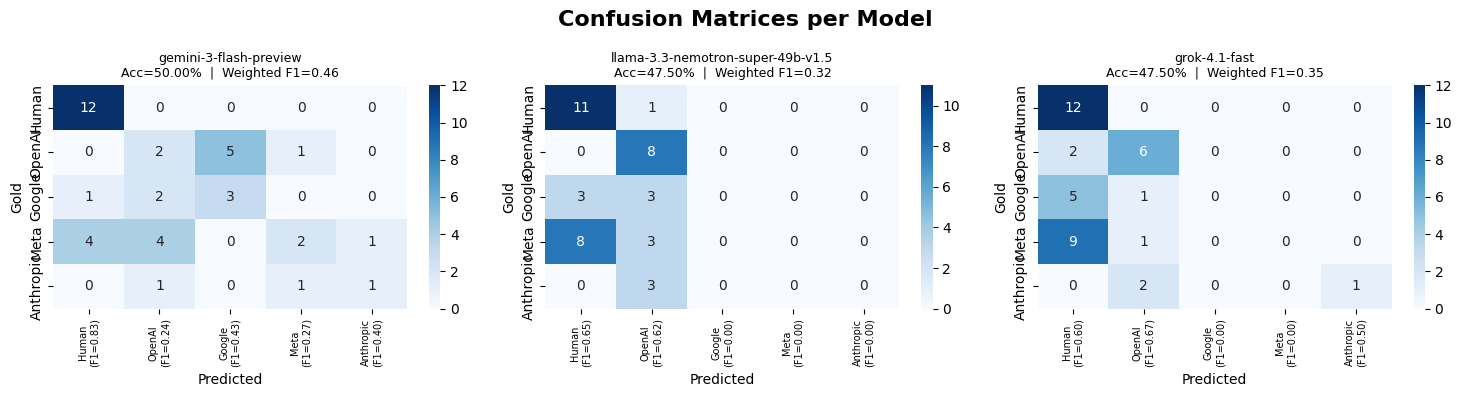

In [37]:

plot_model_comparison_matrix(best_results, test)

### Zero-Shot Classification — Conclusions

#### Current Experiment (40 samples)

> No model reached the ≥60% accuracy threshold.

| Model                                    | Accuracy | Cost ($)  |
|------------------------------------------|----------|-----------|
| nvidia/llama-3.3-nemotron-super-49b-v1.5 | 47.50%   | 0.018386  |
| google/gemini-3-flash-preview            | 50.00%   | 0.006906  |
| x-ai/grok-4.1-fast                       | 47.50%   | 0.019437  |

---

#### From Previous Experiment (20 samples)

> Final model selection was originally based on this smaller benchmark.  
> Due to LLM stochasticity, results are not strictly reproducible.

| Model                                    | Accuracy | Cost ($)  |
|------------------------------------------|----------|-----------|
| x-ai/grok-3-mini                         | **65.00%** | 0.010345  |
| x-ai/grok-4.1-fast                       | **65.00%** | 0.009126  |
| nvidia/llama-3.3-nemotron-super-49b-v1.5 | 60.00%   | **0.008970** |

---

#### Key Observations
- **Gemini 3.1 Flash Lite** shows the best **cost-performance trade-off** in the larger sample.
- **Nemotron (Llama 3.3)** remains competitive in accuracy but is significantly more expensive.
- **Grok-4.1-fast**, previously top-performing, did not maintain its advantage on the 40 sample test.
---

#### Next Steps

- Run **few-shot classification** with:
    - 10, 50, and 100 support examples
- Using these top 2 models from the previous 20 samples experiment:  
    - `x-ai/grok-4.1-fast` and `nvidia/llama-3.3-nemotron-super-49b-v1.5`

## 6. Few-shot classification

In few-shot prompting, we include a small number of labeled examples in the prompt.

In [ ]:
# models selected for few-shot classification `x-ai/grok-4.1-fast` and `nvidia/llama-3.3-nemotron-super-49b-v1.5`

LLM_MODELS_TOP2 = {
     "nvidia/llama-3.3-nemotron-super-49b-v1.5": {
        "input": 0.10 / 1_000,  
        "output": 0.399 / 1_000,  
    },
        "x-ai/grok-4.1-fast": {
        "input": 0.154 / 1_000,   # $ per 1K input tokens 
        "output": 0.50 / 1_000,   # $ per 1K output tokens
    }
}

In [38]:
# few shot prompt builder and support examples generator

def build_few_shot_prompt(example, support_examples):
    labels = ", ".join(label_map.keys())

    system_prompt = f"""You are a Forensic Linguist. Your task is to identify the linguistic origin of the provided text. 
Provided that the text may have been generated by a human or by one of several AI models, analyze the writing style, syntax, and vocabulary to determine its source, from one of the following categories: {labels}.

-----------------------

EVALUATION CRITERIA:
- Analyze the syntactic patterns, vocabulary choice, and structural flow.
- Consider the presence of synthetic artifacts versus natural human variance.
- Focus on the technical 'DNA' of the writing.
- You can consider other meaningful attributes that you identify as relevant to the classification task.
- Reason your analysis based on linguistic features, not on content or factual accuracy.
- Evaluate your criteria based on the following examples, which include a variety of writing styles and sources:

{format_support_examples(support_examples)}

----------------------

RESPONSE FORMAT:
Return ONLY the label category:
<label>"""

    prompt = f"Analyze and classify this text:\n\n\"{example['Text']}\""
    return system_prompt, prompt

def format_support_examples(support_examples):
    formatted = ""
    for ex in support_examples:
        formatted += f"\tExample:\n\t\tLabel: {ex['label_name']}\n\t\tText: \"{ex['Text']}\"\n\n"
    return formatted

def generate_support_examples(num_per_labels = 1, biased = None):
    # create a support set from the training subset
    #
    # Suggested strategy:
    # - pick one example for each label
    # - store them in support_examples
    # - verify that all 4 labels are covered

    # Your code here
    support_examples = []

    for label in LABELS:
        i = 0
        for idx, row in df_train.iterrows():
            if row["label_name"] == label:
                support_examples.append(row)
                i += 1

                if i >= num_per_labels:
                    break


    if biased is not None and biased in LABELS.values():
        # add extra examples of the biased label
        i = 0
        for idx, row in df_train.iterrows():
            if row["label_name"] == biased:
                support_examples.append(row)
                i += 1
                
                if i >= num_per_labels:
                    break

    random.shuffle(support_examples)

    for ex in support_examples:
        #print the label name and formatted example
        print(f"Label: {ex['label_name']}")
        print(f"Example: {ex['Text']}")
        print("-" * 80)

    return support_examples

In [ ]:
# different sizes of support examples collections

support_examples_2 = generate_support_examples(num_per_labels=2)
support_examples_5 = generate_support_examples(num_per_labels=5)
support_examples_10 = generate_support_examples(num_per_labels=10)
support_examples_20 = generate_support_examples(num_per_labels=20)

Label: Google
Example: Flag Manicure On Reddit Is The Coolest Thing We've Seen All Day (PHOTOS) May 14, 2013 - Forget your basic red and white stripes, the latest nail art trend sweeping the internet is a patriotic explosion of color: the flag manicure. Reddit user "StarSpangledNails" ignited a firestorm of excitement yesterday with a post showcasing their intricate, hand-painted American flag manicure. The post, titled "My new nails are ready for Memorial Day!", quickly went viral, garnering thousands of upvotes and comments within hours. The manicure features a bold red base with meticulously painted white stars on each nail, culminating in a vibrant blue stripe across the tips, mimicking the iconic American flag. "I've always loved nail art, and I wanted to
--------------------------------------------------------------------------------
Label: OpenAI
Example: In storytelling, an arc refers to the overall structure or shape of a story. It refers to the way that the plot and character

In [ ]:
# evaluating the top two models, to select one final model

test = df_test.sample(n=20, random_state=SEED)
gold = test['label_name']

best_results_top2  = {}

for model in LLM_MODELS_TOP2.keys():
  print(f"Running experiment with model: {model}")

  preds, raw, usage, experiment_cost = run_experiment(
    model,
    test,
    build_few_shot_prompt,
    support_examples=support_examples_10,
  )

  running_cost += experiment_cost
  best_results_top2[model] = {
    "preds": preds,
    "raw": raw,
    "usage": usage,
    "accuracy": calculate_accuracy(preds, gold)
  }

  print(f"\tAccuracy: {best_results_top2[model]['accuracy']:.2%}\n\tCost for model {model}: ${experiment_cost:.6f}")
  print(f"\tTotal running cost: ${running_cost:.6f}")

Running experiment with model: nvidia/llama-3.3-nemotron-super-49b-v1.5
		Example 167182: Predicted: OpenAI, Gold: OpenAI, Usage: {'prompt_tokens': 7720, 'completion_tokens': 774, 'total_tokens': 8494, 'cached_tokens': 0, 'cost': 0.0010816}, cost: 0.0010816
		Example 4244: Predicted: Meta, Gold: Meta, Usage: {'prompt_tokens': 7734, 'completion_tokens': 655, 'total_tokens': 8389, 'cached_tokens': 0, 'cost': 0.0010354}, cost: 0.0010354
		Example 72516: Predicted: OpenAI, Gold: OpenAI, Usage: {'prompt_tokens': 7732, 'completion_tokens': 537, 'total_tokens': 8269, 'cached_tokens': 0, 'cost': 0.000988}, cost: 0.000988
		Example 147375: Predicted: Human, Gold: Human, Usage: {'prompt_tokens': 7680, 'completion_tokens': 475, 'total_tokens': 8155, 'cached_tokens': 0, 'cost': 0.000958}, cost: 0.000958
		Example 185489: Predicted: OpenAI, Gold: Human, Usage: {'prompt_tokens': 7684, 'completion_tokens': 766, 'total_tokens': 8450, 'cached_tokens': 0, 'cost': 0.0010748}, cost: 0.0010748
		Example 67

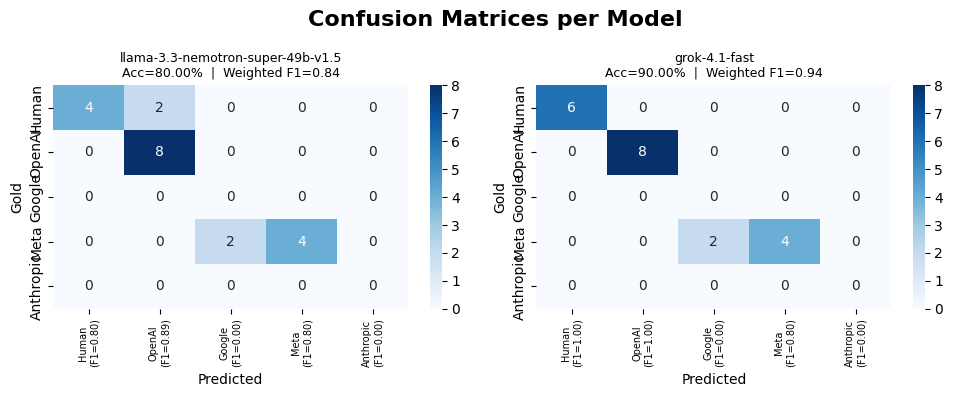

In [48]:
plot_model_comparison_matrix(best_results_top2, test)

In [ ]:
# evaluating top model 'x-ai/grok-4.1-fast', with different number of support examples, to see the impact of the number of examples in the performance and cost

results_top_model = {}
LLM_TOP_MODEL= "x-ai/grok-4.1-fast"

print(f"Running experiment with model: {LLM_TOP_MODEL}_2")
preds, raw, usage, experiment_cost = run_experiment(
  LLM_TOP_MODEL,
  test,
  build_few_shot_prompt,
  support_examples=support_examples_2,
)
running_cost += experiment_cost
results_top_model[LLM_TOP_MODEL + "_2"] = {
  "preds": preds,
  "raw": raw,
  "usage": usage,
  "accuracy": calculate_accuracy(preds, gold)
}


print(f"\tAccuracy: {results_top_model[LLM_TOP_MODEL + '_2']['accuracy']:.2%}\n\tCost for model {LLM_TOP_MODEL}_2: ${experiment_cost:.6f}")
print(f"\tTotal running cost: ${running_cost:.6f}")

print(f"Running experiment with model: {LLM_TOP_MODEL}_5")

reds, raw, usage, experiment_cost = run_experiment(
  LLM_TOP_MODEL,
  test,
  build_few_shot_prompt,
  support_examples=support_examples_5,
)
running_cost += experiment_cost
results_top_model[LLM_TOP_MODEL + "_5"] = {
  "preds": preds,
  "raw": raw,
  "usage": usage,
  "accuracy": calculate_accuracy(preds, gold)
}
print(f"\tAccuracy: {results_top_model[LLM_TOP_MODEL + '_5']['accuracy']:.2%}\n\tCost for model {LLM_TOP_MODEL}_5: ${experiment_cost:.6f}")
print(f"\tTotal running cost: ${running_cost:.6f}")

print(f"Running experiment with model: {LLM_TOP_MODEL}_10")

preds, raw, usage, experiment_cost = run_experiment(
  LLM_TOP_MODEL,
  test,
  build_few_shot_prompt,
  support_examples=support_examples_10,
)

running_cost += experiment_cost
results_top_model[LLM_TOP_MODEL + "_10"] = {
  "preds": preds,
  "raw": raw,
  "usage": usage,
  "accuracy": calculate_accuracy(preds, gold)
}

print(f"\tAccuracy: {results_top_model[LLM_TOP_MODEL + '_10']['accuracy']:.2%}\n\tCost for model {LLM_TOP_MODEL}_10: ${experiment_cost:.6f}")
print(f"\tTotal running cost: ${running_cost:.6f}")

print(f"Running experiment with model: {LLM_TOP_MODEL}_20")

preds, raw, usage, experiment_cost = run_experiment(
  LLM_TOP_MODEL,
  test,
  build_few_shot_prompt,
  support_examples=support_examples_20,
)
running_cost += experiment_cost
results_top_model[LLM_TOP_MODEL + "_20"] = {
  "preds": preds,
  "raw": raw,
  "usage": usage,
  "accuracy": calculate_accuracy(preds, gold)
}
print(f"\tAccuracy: {results_top_model[LLM_TOP_MODEL + '_20']['accuracy']:.2%}\n\tCost for model {LLM_TOP_MODEL}_20: ${experiment_cost:.6f}")
print(f"\tTotal running cost: ${running_cost:.6f}")

Running experiment with model: x-ai/grok-4.1-fast_2
		Example 64622: Predicted: Human, Gold: Human, Usage: {'prompt_tokens': 2047, 'completion_tokens': 443, 'total_tokens': 2490, 'cached_tokens': 150, 'cost': 0.0006084}, cost: 0.0006084
		Example 122831: Predicted: Google, Gold: Google, Usage: {'prompt_tokens': 2107, 'completion_tokens': 575, 'total_tokens': 2682, 'cached_tokens': 150, 'cost': 0.0006864}, cost: 0.0006864
		Example 167182: Predicted: OpenAI, Gold: OpenAI, Usage: {'prompt_tokens': 2101, 'completion_tokens': 511, 'total_tokens': 2612, 'cached_tokens': 150, 'cost': 0.0006532}, cost: 0.0006532
		Example 123157: Predicted: Human, Gold: Human, Usage: {'prompt_tokens': 2107, 'completion_tokens': 497, 'total_tokens': 2604, 'cached_tokens': 150, 'cost': 0.0006474}, cost: 0.0006474
		Example 102581: Predicted: Human, Gold: Human, Usage: {'prompt_tokens': 2087, 'completion_tokens': 688, 'total_tokens': 2775, 'cached_tokens': 150, 'cost': 0.0007389}, cost: 0.0007389
		Example 11470

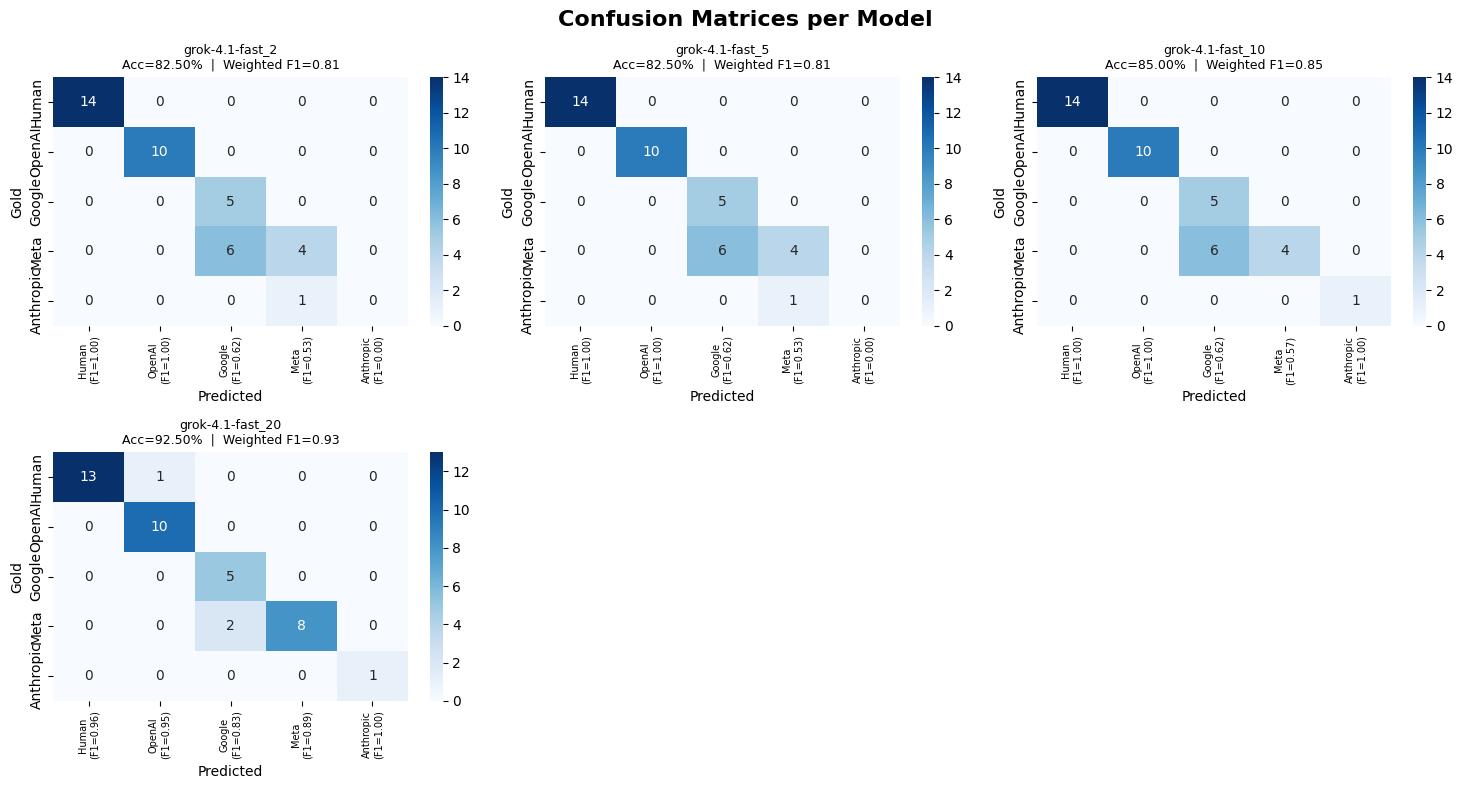

In [68]:
plot_model_comparison_matrix(results_top_model, test)

### Few-shot Classification — Conclusions

#### Performance of the Top 2 Models (with `support_examples_10`, 40 samples)

| Model | Accuracy |
|---|---:|
| `nvidia/llama-3.3-nemotron-super-49b-v1.5` | **80.0%** |
| `x-ai/grok-4.1-fast` | **90.0%** |

**Conclusion:** `x-ai/grok-4.1-fast` outperformed the NVIDIA model in this few-shot setup.

---

#### Impact of Support Example Count (`x-ai/grok-4.1-fast`, 40 samples)

| Configuration | Accuracy | PRICE |
|---|---|---|
| `grok-4.1-fast_2` | 82.5% | $0.026638 | 
| `grok-4.1-fast_5` | 82.5% | $0.043600 |
| `grok-4.1-fast_10` | 85.0% |  $0.063491 |
| `grok-4.1-fast_20` | **92.5%** | $0.103718 |

**Overall takeaway:** more support examples improved classification performance, with the best result at `20-shot`, but the price almost doubles per request.

---

#### Next Step

Move to **RAG** to select semantically relevant support examples, aiming to:

- further increase accuracy;
- reduce the number of examples required in the prompt;
- improve cost/token efficiency.

## Adding RAG to improve support examples

https://huggingface.co/blog/ngxson/make-your-own-rag

In [ ]:
# basic RAG functions for embedding, building vector DB, and retrieving support examples based on cosine similarity of embeddings

import ollama

EMBEDDING_MODEL = "hf.co/CompendiumLabs/bge-base-en-v1.5-gguf"
VECTOR_DB = []

# Keep support examples concise in prompts to avoid context overflows later.
SUPPORT_TEXT_MAX_CHARS = 120

def _sanitize_text(text: str) -> str:
    t = str(text).replace("\x00", " ").strip()[:SUPPORT_TEXT_MAX_CHARS]
    if not t:
        return " "
    return t

def embed_text(text, label_name):
    clean_text = _sanitize_text(text)

    # For embeddings, allow Ollama to truncate when needed instead of failing.
    embedding = ollama.embed(
        model=EMBEDDING_MODEL,
        input=clean_text,
        truncate=True,
    )["embeddings"][0]

    VECTOR_DB.append({
        "Text": clean_text,
        "embedding": embedding,
        "label_name": label_name,
    })

def build_vector_db(df_train):
    VECTOR_DB.clear()  # Clear existing rows on rerun
    total = len(df_train)

    if total == 0:
        print("Progress: |" + "-" * 50 + "| 100% (0/0)")
        return

    start_time = time.time()
    failed = 0

    for i, (_, row) in enumerate(df_train.reset_index(drop=True).iterrows(), start=1):
        try:
            embed_text(row["Text"], row["label_name"])
        except Exception as e:
            failed += 1
            print(f"\nWarning: failed to embed row {i}/{total}: {e}")

        elapsed = time.time() - start_time
        avg_time = elapsed / i
        remaining = avg_time * (total - i)

        mins, secs = divmod(int(remaining), 60)
        eta_str = f"{mins}m {secs}s" if mins > 0 else f"{secs}s"

        pct = int((i / total) * 100)
        filled = pct // 2  # 50 chars wide bar
        bar = "#" * filled + "-" * (50 - filled)
        print(f"\rProgress: |{bar}| {pct:3d}% ({i}/{total}) - ETA: {eta_str}   ", end="")

    print()
    print(f"Vector DB build done: {len(VECTOR_DB)} ok, {failed} failed")

def cosine_similarity(a, b):
    a = np.array(a, dtype=np.float32)
    b = np.array(b, dtype=np.float32)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))

# this is very slow, for larger datasets
def retrieve_balanced(query_text, total_k=10, min_per_label=1, top_pool=50):
    if not VECTOR_DB:
        raise ValueError("VECTOR_DB is empty. Run build_vector_db(df_train) first.")

    query_embedding = ollama.embed(
        model=EMBEDDING_MODEL,
        input=_sanitize_text(query_text),
        truncate=True,
    )["embeddings"][0]

    scored = []
    for item in VECTOR_DB:
        s = cosine_similarity(query_embedding, item["embedding"])
        scored.append((s, item))

    # 1) Global ranking by similarity
    scored.sort(key=lambda x: x[0], reverse=True)

    if top_pool is not None and top_pool > 0:
        scored = scored[:top_pool]

    # 2) Guarantee minimum per-label coverage
    selected = []
    selected_keys = set()

    for label in LABELS:
        picked = 0
        for score, item in scored:
            key = (item["label_name"], item["Text"])
            if item["label_name"] != label or key in selected_keys:
                continue
            selected.append((score, item))
            selected_keys.add(key)
            picked += 1
            if picked >= min_per_label:
                break

    # 3) Fill remaining slots by best leftovers
    for score, item in scored:
        if len(selected) >= total_k:
            break
        key = (item["label_name"], item["Text"])
        if key in selected_keys:
            continue
        selected.append((score, item))
        selected_keys.add(key)

    support_examples = [item for _, item in selected[:total_k]]

    return support_examples


In [83]:
build_vector_db(df_train)

Progress: |##################################################| 100% (149657/149657) - ETA: 0s        
Vector DB build done: 149657 ok, 0 failed


In [ ]:
print("total_vectors:", len(VECTOR_DB))
print("embedding_dim:", len(VECTOR_DB[0]["embedding"]) if VECTOR_DB else 0)
print("labels:", ", ".join(sorted({x["label_name"] for x in VECTOR_DB})) if VECTOR_DB else "")

## Explort embeddings to a json file
with open("embedding_vector_RAG.json", "w") as f:
    json.dump(VECTOR_DB, f, indent=2)

total_vectors: 149657
embedding_dim: 768
labels: Anthropic, Google, Human, Meta, OpenAI


In [21]:
# REloads embeddings from json file
with open("embedding_vector_RAG.json", "r") as f:
    VECTOR_DB = json.load(f)

In [ ]:
# function to run the experiment with RAG

def run_experiment_withRAG(
    model,
    dataset_split,
    prompt_builder, # fn that builds the prompt for  example
    sleep_seconds=0.0,
    total_k=10,
    min_per_label=2,
    top_pool=50,
    model_call_func=CALL_OPENAI_API
):
    predictions = []
    raw_outputs = []
    usage_details = []

    experiment_cost = 0.0
    prompt = ""
 
    for idx, example in dataset_split.iterrows():

        support_examples = retrieve_balanced(example["Text"], total_k=total_k, min_per_label=min_per_label, top_pool=top_pool) 
        system_prompt, prompt = prompt_builder(example, support_examples)

        raw = ""
        
        try:
            raw, usage = model_call_func(model, system_prompt, prompt)
            pred = normalize_prediction(raw)
            experiment_cost += usage["cost"]
            print(f"\t\tExample {idx}: Predicted: {pred}, Gold: {example['label_name']}, Usage: {usage}, cost: {usage['cost']}")
        except Exception as e:
            raw = f'ERROR: {str(e)}'
            usage = {"cost": 0.0}
            pred = None

        raw_outputs.append(raw)
        predictions.append(pred)
        usage_details.append(usage)

        # optional pause to respect rate limits
        time.sleep(sleep_seconds)

    return predictions, raw_outputs, usage_details, experiment_cost

In [ ]:
# running few shot with RAG retrieval, with 10 total support examples 

results_rag = {}
LLM_TOP_MODEL= "x-ai/grok-4.1-fast"

# comparable in token cost with the 2 support examples few-shot, but with dynamic retrieval of the most relevant examples for each test instance
print(f"Running experiment with model: {LLM_TOP_MODEL}_WITH_RAG_10")
preds, raw, usage, experiment_cost = run_experiment_withRAG(
  LLM_TOP_MODEL,
  test,
  build_few_shot_prompt,
  total_k=10,
)

running_cost += experiment_cost
results_rag[LLM_TOP_MODEL + "_WITH_RAG_10"] = {
  "preds": preds,
  "raw": raw,
  "usage": usage,
  "accuracy": calculate_accuracy(preds, gold)
}


print(f"\tAccuracy: {results_rag[LLM_TOP_MODEL + '_WITH_RAG_10']['accuracy']:.2%}\n\tCost for model {LLM_TOP_MODEL}_WITH_RAG_10: ${experiment_cost:.6f}")
print(f"\tTotal running cost: ${running_cost:.6f}")

label_name
Human        14
OpenAI       10
Meta         10
Google        5
Anthropic     1
Name: count, dtype: int64
Running experiment with model: x-ai/grok-4.1-fast_WITH_RAG
		Example 64622: Predicted: Human, Gold: Human, Usage: {'prompt_tokens': 829, 'completion_tokens': 720, 'total_tokens': 1549, 'cached_tokens': 150, 'cost': 0.0005033}, cost: 0.0005033
		Example 122831: Predicted: Meta, Gold: Google, Usage: {'prompt_tokens': 937, 'completion_tokens': 1605, 'total_tokens': 2542, 'cached_tokens': 150, 'cost': 0.0009674}, cost: 0.0009674
		Example 167182: Predicted: OpenAI, Gold: OpenAI, Usage: {'prompt_tokens': 874, 'completion_tokens': 513, 'total_tokens': 1387, 'cached_tokens': 150, 'cost': 0.0004088}, cost: 0.0004088
		Example 123157: Predicted: Human, Gold: Human, Usage: {'prompt_tokens': 960, 'completion_tokens': 488, 'total_tokens': 1448, 'cached_tokens': 959, 'cost': 0.00029215}, cost: 0.00029215
		Example 102581: Predicted: Human, Gold: Human, Usage: {'prompt_tokens': 870, '

In [ ]:
# running few shot with RAG retrieval, with 20 total support examples 

# comparable in token cost with the 4 support examples few-shot, but with dynamic retrieval of the most relevant examples for each test instance
print(f"Running experiment with model: {LLM_TOP_MODEL}_WITH_RAG")
preds, raw, usage, experiment_cost = run_experiment_withRAG(
  LLM_TOP_MODEL,
  test,
  build_few_shot_prompt,
  total_k=20
)

running_cost += experiment_cost
results_rag[LLM_TOP_MODEL + "_WITH_RAG_20"] = {
  "preds": preds, 
  "raw": raw,
  "usage": usage,
  "accuracy": calculate_accuracy(preds, gold)
}


print(f"\tAccuracy: {results_rag[LLM_TOP_MODEL + '_WITH_RAG_20']['accuracy']:.2%}\n\tCost for model {LLM_TOP_MODEL}_WITH_RAG_20: ${experiment_cost:.6f}")
print(f"\tTotal running cost: ${running_cost:.6f}")

Running experiment with model: x-ai/grok-4.1-fast_WITH_RAG
		Example 64622: Predicted: Human, Gold: Human, Usage: {'prompt_tokens': 1220, 'completion_tokens': 603, 'total_tokens': 1823, 'cached_tokens': 150, 'cost': 0.000523}, cost: 0.000523
		Example 122831: Predicted: Google, Gold: Google, Usage: {'prompt_tokens': 1395, 'completion_tokens': 1336, 'total_tokens': 2731, 'cached_tokens': 150, 'cost': 0.0009245}, cost: 0.0009245
		Example 167182: Predicted: OpenAI, Gold: OpenAI, Usage: {'prompt_tokens': 1265, 'completion_tokens': 484, 'total_tokens': 1749, 'cached_tokens': 150, 'cost': 0.0004725}, cost: 0.0004725
		Example 123157: Predicted: Human, Gold: Human, Usage: {'prompt_tokens': 1368, 'completion_tokens': 709, 'total_tokens': 2077, 'cached_tokens': 150, 'cost': 0.0006056}, cost: 0.0006056
		Example 102581: Predicted: Human, Gold: Human, Usage: {'prompt_tokens': 1272, 'completion_tokens': 466, 'total_tokens': 1738, 'cached_tokens': 332, 'cost': 0.0004376}, cost: 0.0004376
		Example

In [ ]:
# running few shot with RAG retrieval, with 50 total support examples 

# comparable in token cost with the 10 support examples few-shot, but with dynamic retrieval of the most relevant examples for each test instance
print(f"Running experiment with model: {LLM_TOP_MODEL}_WITH_RAG_50")
preds, raw, usage, experiment_cost = run_experiment_withRAG(
  client,
  LLM_TOP_MODEL,
  test,
  build_few_shot_prompt,
  total_k=50,
  min_per_label=4,
  top_pool=150
)

running_cost += experiment_cost
results_rag[LLM_TOP_MODEL + "_WITH_RAG_50"] = {
  "preds": preds, 
  "raw": raw,
  "usage": usage,
  "accuracy": calculate_accuracy(preds, gold)
}


print(f"\tAccuracy: {results_rag[LLM_TOP_MODEL + '_WITH_RAG_50']['accuracy']:.2%}\n\tCost for model {LLM_TOP_MODEL}_WITH_RAG_50: ${experiment_cost:.6f}")
print(f"\tTotal running cost: ${running_cost:.6f}")

Running experiment with model: x-ai/grok-4.1-fast_WITH_RAG_50
		Example 64622: Predicted: Human, Gold: Human, Usage: {'prompt_tokens': 2444, 'completion_tokens': 527, 'total_tokens': 2971, 'cached_tokens': 2443, 'cost': 0.00038585}, cost: 0.00038585
		Example 122831: Predicted: Google, Gold: Google, Usage: {'prompt_tokens': 2738, 'completion_tokens': 1017, 'total_tokens': 3755, 'cached_tokens': 2114, 'cost': 0.000739}, cost: 0.000739
		Example 167182: Predicted: OpenAI, Gold: OpenAI, Usage: {'prompt_tokens': 2444, 'completion_tokens': 501, 'total_tokens': 2945, 'cached_tokens': 1889, 'cost': 0.00045595}, cost: 0.00045595
		Example 123157: Predicted: Human, Gold: Human, Usage: {'prompt_tokens': 2551, 'completion_tokens': 505, 'total_tokens': 3056, 'cached_tokens': 150, 'cost': 0.0007402}, cost: 0.0007402
		Example 102581: Predicted: Human, Gold: Human, Usage: {'prompt_tokens': 2451, 'completion_tokens': 412, 'total_tokens': 2863, 'cached_tokens': 332, 'cost': 0.0006464}, cost: 0.0006464

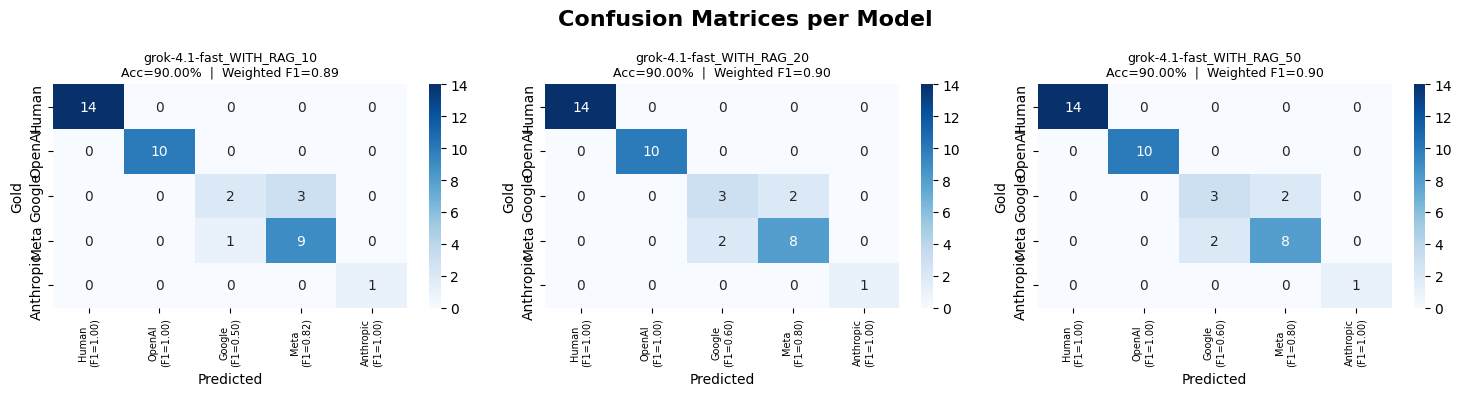

In [111]:
plot_model_comparison_matrix(results_rag, test)

### Few-shot Classification with RAG — Conclusions

RAG achieved results close to the best static few-shot setup while using **dynamically retrieved support examples** and substantially **lower cost**.

#### Impact of Support Example Strategy (`x-ai/grok-4.1-fast`, 40 samples)

| Configuration | Accuracy | Cost | Notes |
|---|---:|---:|---|
| `grok-4.1-fast_2`  | 82.5% | $0.026638 | Static few-shot (`2` examples/label, `10` total) |
| `grok-4.1-fast_5`  | 82.5% | $0.043600 | Static few-shot (`5` examples/label, `25` total) |
| `grok-4.1-fast_10` | 85.0% | $0.063491 | Static few-shot (`10` examples/label, `50` total) |
| `grok-4.1-fast_20` | **92.5%** | $0.103718 | Static few-shot (`20` examples/label, `100` total) |
| `grok-4.1-fast_WITH_RAG_10` | 90.0% | **$0.020339** | Dynamic RAG (`10` retrieved total, ~`2`/label) |
| `grok-4.1-fast_WITH_RAG_20` | 90.0% | $0.023844 | Dynamic RAG (`20` retrieved total, ~`4`/label) |
| `grok-4.1-fast_WITH_RAG_50` | 90.0% | $0.034305 | Dynamic RAG (`50` retrieved total, ~`10`/label) |

#### Key Insights

- **Best cost-performance tradeoff:** `RAG_10` reached **90.0% accuracy** at the **lowest cost** in this comparison, outperforming static 2-shot, 5-shot, and 10-shot prompting.
- **Near-top accuracy at much lower price:** static `20-shot` produced the best score (**92.5%**), but RAG remained only **2.5 points lower** while costing roughly **5x less**.
- **Dynamic retrieval helps:** selecting semantically relevant examples per query appears more effective than using a fixed support set, especially in lower- and mid-context settings.
- **Diminishing returns:** increasing RAG from 10 to 20 or 50 retrieved examples did **not** improve accuracy.
- **Remaining challenge:** the main errors still appear to come from harder distinctions between stylistically similar classes, especially **Meta vs. Google**.

#### Takeaway

**RAG with 10 dynamic examples** provides the best overall balance of **accuracy, cost, and prompt efficiency** at this moment.

## Fine-Tuning a Local LLM with QLoRA (Unsloth)

### Motivation

While `grok-4.1-fast` + RAG achieves **90% accuracy**, it requires external API calls and per-inference vector retrieval. Fine-tuning a local model aims to **internalize** task-specific reasoning into model weights, eliminating API costs and retrieval latency after training.

---

### Approach: QLoRA (Quantized Low-Rank Adaptation)

**Quantization** loads the base model (`Qwen2.5-0.5B-Instruct`) in **4-bit precision**, compressing weights to fit in consumer VRAM — frozen during training.

> We started with `Qwen2.5-7B-Instruct` and dropped to `0.5B` for faster training cycles, allowing more examples to be trained in the same time.

**LoRA** injects small trainable adapter matrices alongside frozen layers.
---

### LoRA Configuration

| Parameter | Value | Rationale |
|---|---|---|
| `r` | 8 | Adapter rank — reduced for the smaller 0.5B model |
| `lora_alpha` | 16 | Effective scale = $\alpha / r = 2.0$ |
| `target_modules` | attention + MLP | All 7 linear projections per transformer block |
| `lora_dropout` | 0 | Dataset is large and clean |
| `bias` | `"none"` | Minimizes parameter count |
| `use_gradient_checkpointing` | `"unsloth"` | Trades compute for VRAM savings |

---

### Finetunning Configuration 

| Parameter | Value | Rationale |
|---|---|---|
| `per_device_train_batch_size` | 8 | Larger batch for stable gradients |
| `gradient_accumulation_steps` | 2 | Effective batch size = 16 |
| `num_train_epochs` | 3 |  |
| `learning_rate` | 2e-4 | Standard QLoRA learning rate |
| `lr_scheduler_type` | cosine | Smooth decay schedule |
| `optim` | adamw_8bit | Memory-efficient optimizer |
| `eval_strategy` | steps (every 100) | Monitor validation loss during training |

---

### Training Dataset Construction

Training data uses the **zero-shot prompt format**:

1. Sample texts from `df_train`
2. `build_zero_shot_prompt` constructs the Forensic Linguist system prompt + user query
3. Store `{"input": [system_msg, user_msg], "output": gold_label}` as training samples

This **prompt-aligned fine-tuning** teaches the model to produce correct labels given exactly the same zero-shot prompt structure used at inference time.

> **Note:** RAG-based few-shot prompts (`retrieve_balanced` + `build_few_shot_prompt`) were originally planned but disabled — the zero-shot format was chosen to keep training sequences shorter and avoid the embedding retrieval bottleneck during dataset generation.

---

In [ ]:
!pip install  unsloth

44659.30s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [ ]:
## loading base model, using unsloth
from unsloth import FastLanguageModel
force_fine_tuning = False  # set to True to force fine-tuning even if a checkpoint is available

#default_model_name = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit"
default_model_name = "unsloth/Qwen2.5-0.5B-Instruct-bnb-4bit"
finetune_checkpoint = "outputs/Qwen2.5-0.5B-Instruct-bnb-4bit_finetuned"

model_name = default_model_name 
if(os.path.exists(finetune_checkpoint) and not force_fine_tuning):
    print(f"Loading fine-tuned model from checkpoint: {finetune_checkpoint}")
    model_name = finetune_checkpoint

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.3.10: Fast Qwen2 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA GeForce RTX 5070 Ti. Num GPUs = 1. Max memory: 15.466 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 2198.06it/s]


unsloth/qwen2.5-0.5b-instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [11]:
# apply PEFT only if we are loading the base model, if we are loading a checkpoint, we assume it is already applied 

if model_name == default_model_name: 
    model = FastLanguageModel.get_peft_model(
        model,
        r = 8, #16,
        target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                          "gate_proj", "up_proj", "down_proj"],
        lora_alpha = 16, # 32,
        lora_dropout = 0,          
        bias = "none",
        use_gradient_checkpointing = "unsloth",
        random_state = 42,
        use_rslora = False,
        loftq_config = None,
    )

Unsloth 2026.3.10 patched 24 layers with 24 QKV layers, 24 O layers and 24 MLP layers.


In [12]:
## Generating a training dataset using the zero-shot prompt format.
## Each sample pairs the Forensic Linguist system prompt + user text with the gold label as expected output.

def generate_fine_tuning_dataset(df_train, limit: Optional[int] = None):
    fine_tuning_data = []
    
    df = df_train if limit is None or limit <= 0 else df_train.head(limit)
    total = len(df)

    if total == 0:
        return fine_tuning_data

    failed = 0

    for i, (_, row) in enumerate(df.iterrows(), start=1):
        try:
            text = row["Text"]
            gold_label = row["label_name"]

            #support_examples = retrieve_balanced(text, total_k=10, min_per_label=2, top_pool=50)
            system_prompt, prompt = build_zero_shot_prompt({"Text": text})

            messages = [
            {
                "role": "system", 
                "content": system_prompt
            },
            {
                "role": "user", 
                "content": prompt
            }]

            fine_tuning_data.append({
                "input": messages,
                "output": gold_label
            })
        except Exception as e:
            failed += 1
            print(f"\nWarning: failed to process row {i}/{total}: {e}")

    print()
    print(f"Fine-tuning dataset build done: {len(fine_tuning_data)} ok, {failed} failed")

    return fine_tuning_data

fine_tuning_dataset = generate_fine_tuning_dataset(df_train)
display(fine_tuning_dataset[:2])


Fine-tuning dataset build done: 102596 ok, 0 failed


[{'input': [{'role': 'system',
    'content': "You are a Forensic Linguist. Your task is to identify the linguistic origin of the provided text. \nProvided that the text may have been generated by a human or by one of several AI models, analyze the writing style, syntax, and vocabulary to determine its source, from one of the following categories: Human, OpenAI, Google, Meta, Anthropic.\n\nEVALUATION CRITERIA:\n- Analyze the syntactic patterns, vocabulary choice, and structural flow.\n- Consider the presence of synthetic artifacts versus natural human variance.\n- Focus on the technical 'DNA' of the writing.\n- You can consider other meaningful attributes that you identify as relevant to the classification task.\n- Reason your analysis based on linguistic features, not on content or factual accuracy.\n\nRESPONSE FORMAT:\nReturn ONLY the label category:\n<label>"},
   {'role': 'user',
    'content': 'Analyze and classify this text:\n\n"If you are a beginner investor, it is important to 

In [13]:
# applies template to dataset and converts it to Hugging Face Dataset format for fine-tuning with PEFT LoRA

from datasets import Dataset

hf_dataset = Dataset.from_list(fine_tuning_dataset)

dataset = Dataset.from_list([
{
    "conversations": [
    {"role": "system", "content": row["input"][0]["content"]},
    {"role": "user", "content": row["input"][1]["content"]},
    {"role": "assistant", "content": row["output"]},
    ]
} for row in fine_tuning_dataset ])


In [14]:
# more standardization required for the dataset

from unsloth import standardize_sharegpt
dataset = standardize_sharegpt(dataset)

split_dataset = dataset.train_test_split(test_size=0.005, seed=SEED)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print(f"Train examples: {len(train_dataset)}")
print(f"Eval examples: {len(eval_dataset)}")


Unsloth: Standardizing formats (num_proc=16):   0%|          | 0/102596 [00:00<?, ? examples/s]

Unsloth: Standardizing formats (num_proc=16): 100%|██████████| 102596/102596 [00:18<00:00, 5627.15 examples/s]

Train examples: 102083
Eval examples: 513


In [25]:
dataset[0]

{'conversations': [{'content': "You are a Forensic Linguist. Your task is to identify the linguistic origin of the provided text. \nProvided that the text may have been generated by a human or by one of several AI models, analyze the writing style, syntax, and vocabulary to determine its source, from one of the following categories: Human, OpenAI, Google, Meta, Anthropic.\n\nEVALUATION CRITERIA:\n- Analyze the syntactic patterns, vocabulary choice, and structural flow.\n- Consider the presence of synthetic artifacts versus natural human variance.\n- Focus on the technical 'DNA' of the writing.\n- You can consider other meaningful attributes that you identify as relevant to the classification task.\n- Reason your analysis based on linguistic features, not on content or factual accuracy.\n\nRESPONSE FORMAT:\nReturn ONLY the label category:\n<label>",
   'role': 'system'},
  {'content': 'Analyze and classify this text:\n\n"If you are a beginner investor, it is important to start with a di

In [ ]:
# training parameters and trainer setup using trl SFTTrainer, with the formatting function to apply the chat template to the conversations in the dataset

from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

def formatting_prompts_func(example):
    conversations = example["conversations"]

    # Unsloth may call formatting_func with a single sample first (not a batched dict).
    if conversations and isinstance(conversations[0], dict) and "role" in conversations[0]:
        text = tokenizer.apply_chat_template(
            conversations,
            tokenize=False,
            add_generation_prompt=False,
        )
        return [text]

    # Batched path: a list of conversations (each conversation is a list of role/content dicts).
    texts = []
    for conv in conversations:
        text = tokenizer.apply_chat_template(
            conv,
            tokenize=False,
            add_generation_prompt=False,
        )
        texts.append(text)
    return texts

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset,
    formatting_func = formatting_prompts_func,
    max_seq_length = 2048,
    dataset_num_proc = 4,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 8, 
        per_device_eval_batch_size = 8, 
        gradient_accumulation_steps = 2, 
        warmup_steps = 10,
        num_train_epochs = 3, 
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 10,
        save_total_limit = 2,
        load_best_model_at_end = False,
        metric_for_best_model = "eval_loss",
        greater_is_better = False,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
        eval_strategy = "steps",
        eval_steps = 100,
        save_strategy = "steps",
        save_steps = 1000,
    ),
)


Unsloth: Tokenizing ["text"] (num_proc=16): 100%|██████████| 513/513 [00:32<00:00, 15.65 examples/s]


In [ ]:
# fine tunning of the model, this takes a long time (initial 15 minutes, final 1-2 hours)
# no need if loading from a previous checkpoint, as the checkpoint should already be fine-tuned
if model_name == default_model_name or force_fine_tuning: 
    trainer_stats = trainer.train()
    print(trainer_stats)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 102,083 | Num Epochs = 3 | Total steps = 19,143
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 4,399,104 of 498,431,872 (0.88% trained)


Step,Training Loss,Validation Loss
100,0.950665,0.939511
200,0.918119,0.916765
300,0.875057,0.905684
400,0.919888,0.896524
500,0.890899,0.890915
600,0.891161,0.886584
700,0.902501,0.884334
800,0.863607,0.882257
900,0.862879,0.878337
1000,0.867565,0.875716


Unsloth: Not an error, but Qwen2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
/media/rmca/2016F41316F3E824/ProjetoAP/venv/lib/python3.13/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/media/rmca/2016F41316F3E824/ProjetoAP/venv/lib/python3.13/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE

TrainOutput(global_step=19143, training_loss=0.8132121050450606, metrics={'train_runtime': 7319.3018, 'train_samples_per_second': 41.841, 'train_steps_per_second': 2.615, 'total_flos': 2.4263207226969984e+17, 'train_loss': 0.8132121050450606, 'epoch': 3.0})


In [ ]:
# saving the model and tokenizer after fine-tuning, to be used later for inference and evaluation on the test set
trainer.save_model(finetune_checkpoint)
tokenizer.save_pretrained(finetune_checkpoint)

('outputs/Qwen2.5-0.5B-Instruct-bnb-4bit_finetuned/tokenizer_config.json',
 'outputs/Qwen2.5-0.5B-Instruct-bnb-4bit_finetuned/chat_template.jinja',
 'outputs/Qwen2.5-0.5B-Instruct-bnb-4bit_finetuned/tokenizer.json')

In [18]:
# saves the model in gguf format for efficient inference with Ollama
model.save_pretrained_gguf("model", tokenizer)

Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /home/rmca/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [01:22<00:00, 82.87s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:02<00:00,  2.14s/it]


Unsloth: Merge process complete. Saved to `/media/rmca/2016F41316F3E824/ProjetoAP/model`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q8_0'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...


[unsloth_zoo.llama_cpp|WARNING]Unsloth: Qwen2MoE num_experts patch target not found.


Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['model_gguf/Qwen2.5-0.5B-Instruct.BF16.gguf']
Unsloth: [2] Converting GGUF bf16 into q8_0. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['model_gguf/Qwen2.5-0.5B-Instruct.Q8_0.gguf']
Unsloth: example usage for text only LLMs: /home/rmca/.unsloth/llama.cpp/llama-cli --model model_gguf/Qwen2.5-0.5B-Instruct.Q8_0.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to model_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f model_gguf/Modelfile


{'save_directory': 'model',
 'gguf_directory': 'model_gguf',
 'gguf_files': ['model_gguf/Qwen2.5-0.5B-Instruct.Q8_0.gguf'],
 'modelfile_location': 'model_gguf/Modelfile',
 'want_full_precision': False,
 'is_vlm': False,
 'fix_bos_token': False}

In [19]:
!ollama create Qwenn2.5_0.5B_FineTuned_model -f ./model_gguf/Modelfile 

]11;?\gathering model components ⠙ gathering model components ⠹ gathering model components ⠹ gathering model components 
copying file sha256:b94da2191224c5eedb04cc8df69dd557951db6f7c3cf1e12d9f26895ee73ed97 8% ⠋ gathering model components 
copying file sha256:b94da2191224c5eedb04cc8df69dd557951db6f7c3cf1e12d9f26895ee73ed97 17% ⠙ gathering model components 
copying file sha256:b94da2191224c5eedb04cc8df69dd557951db6f7c3cf1e12d9f26895ee73ed97 34% ⠹ gathering model components 
copying file sha256:b94da2191224c5eedb04cc8df69dd557951db6f7c3cf1e12d9f26895ee73ed97 53% ⠸ gathering model components 
copying file sha256:b94da2191224c5eedb04cc8df69dd557951db6f7c3cf1e12d9f26895ee73ed97 61% ⠼ gathering model components 
copying file sha256:b94da2191224c5eedb04cc8df69dd557951db6f7c3cf1e12d9f26895ee73ed97 79% ⠴ gathering model components 
copying file sha256:b94da2191224c5eedb04cc8df69dd557951db6f7c3cf1e12d9f26895ee73ed97 97% ⠦ gathering model components 
copying file sha256:b94da2191224c5eedb04cc8df

In [ ]:
import ollama
MODEL_FINETUNED = "Qwenn2.5_0.5B_FineTuned_model"

def CALL_FINETUNED_OLLAMA(model, System_Prompt, Prompt):
    messages = [
        {"role": "system", "content": System_Prompt},
        {"role": "user", "content": Prompt}
    ]

    completion = ollama.chat(
        model=MODEL_FINETUNED,
        messages=messages,
        options={
            "temperature": 0,
            "num_predict": 8, # to limit the output to a single token, which should be the label
            "top_p": 1.0, # to consider all tokens with cumulative probability up to 1.0
            "top_k": 1, # to consider only the single most probable token at each step, which should be the label
            "repeat_penalty": 1.0, # to not penalize repetition, as we want the model to output the most probable label even if it repeats tokens
            "seed": SEED
        },
    )

    response = completion.message.content

    Usage = {
        "prompt_tokens": -1,
        "completion_tokens": -1,
        "total_tokens": -1,
        "cached_tokens": -1,
        "cost": 0.0
    }

    return response.strip(), Usage

In [31]:
print(f"Running experiment with model: {MODEL_FINETUNED}_OLLAMA")

test = df_test
gold = test['label_name']

preds, raw, usage, experiment_cost = run_experiment(
  MODEL_FINETUNED,
  test,
  build_zero_shot_prompt,
  model_call_func=CALL_FINETUNED_OLLAMA
)

finetune_results = {}
finetune_results[MODEL_FINETUNED] = {
  "preds": preds,
  "raw": raw,
  "usage": usage,
  "accuracy": calculate_accuracy(preds, gold)
}
print(f"\tAccuracy: {finetune_results[MODEL_FINETUNED]['accuracy']:.2%}")


Running experiment with model: Qwenn2.5_0.5B_FineTuned_model_OLLAMA
		Example 102596: Correct: True,  Predicted: OpenAI, Gold: OpenAI, Usage: {'prompt_tokens': -1, 'completion_tokens': -1, 'total_tokens': -1, 'cached_tokens': -1, 'cost': 0.0}, cost: 0.0 | Rows left: 25648
		Example 102597: Correct: True,  Predicted: Google, Gold: Google, Usage: {'prompt_tokens': -1, 'completion_tokens': -1, 'total_tokens': -1, 'cached_tokens': -1, 'cost': 0.0}, cost: 0.0 | Rows left: 25647
		Example 102598: Correct: True,  Predicted: Meta, Gold: Meta, Usage: {'prompt_tokens': -1, 'completion_tokens': -1, 'total_tokens': -1, 'cached_tokens': -1, 'cost': 0.0}, cost: 0.0 | Rows left: 25646
		Example 102599: Correct: True,  Predicted: Human, Gold: Human, Usage: {'prompt_tokens': -1, 'completion_tokens': -1, 'total_tokens': -1, 'cached_tokens': -1, 'cost': 0.0}, cost: 0.0 | Rows left: 25645
		Example 102600: Correct: True,  Predicted: Meta, Gold: Meta, Usage: {'prompt_tokens': -1, 'completion_tokens': -1, '

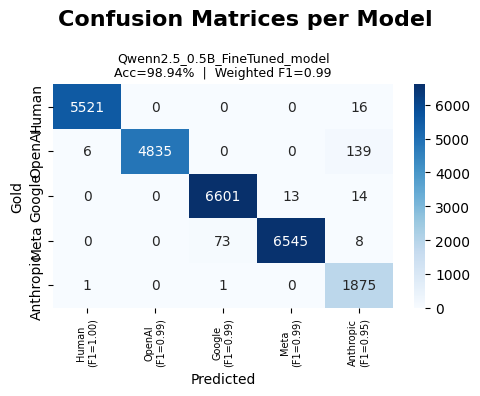

In [32]:
plot_model_comparison_matrix(finetune_results, test)

## Fine-Tuning a Local LLM with QLoRA (Unsloth) – Conclusion

Fine-tuning a local LLM proved to be the most effective approach among all methods evaluated.

A relatively small model (0.5B parameters) was sufficient to learn the classification task with high accuracy. Previous experiments with larger models (7B) did not converge effectively, suggesting that reducing model size enabled more stable training and allowed for longer training cycles within resource constraints.

The final performance was strong:

* **Accuracy:** 98.94%
* **F1 Score:** 0.99

While not perfect, these results significantly outperform zero-shot and few-shot approaches.

### Trade-offs

* **Training time:** ~2 hours
* **Inference time (test set):** ~1 hour
* **Latency:** Higher than non-API-based approaches (e.g., direct neural network inference) due to deployment via Ollama and the overhead of API-based interaction with the model.

### Improvement Opportunities

* Lower learning rate with longer training may further improve generalization
* An hybrid approach combining fine-tuning with RAG may improve edge cases, but:

  * Adds significant complexity
  * Increases both training and inference time substantially
  * Current RAG implementation requires optimization before being viable

---

## Final Comparison

| Approach           | Best Model                   | Accuracy | Notes                                                         |
| ------------------ | ---------------------------- | -------- | ------------------------------------------------------------- |
| Zero-Shot          | `grok-4.1-fast` (20 samples) | 65%      | Dropped to ~50% on 40 samples (`google/gemini-3-flash-preview`)|
| Few-Shot           | `grok-4.1-fast_20` (40 samples)| 92.5%    | High cost per request (20 support examples per label)                 |
| Few-Shot + RAG     | `grok-4.1-fast_WITH_RAG_10` (40 samples)  | 90.0%    | Similar performance across models; adds ~2 support examples per label |
| Fine-Tuned (Local) | `Qwen2.5_0.5B_FineTuned` (25649)   | 98.94%   | Best performance, lowest inference cost, highest setup cost   |
> training all the apprachs with the full 25649 test samples would be to expensive
---

## Final Takeaway

For this type of classification task, when an LLM-based solution is required:

* **Fine-tuning a small model** provides the best balance between accuracy and long-term cost efficiency
* **Few-shot approaches on commercial models** are suitable for rapid experimentation but become expensive at scale
* **Zero-shot approaches on commercial models** are generally not reliable enough for production use in this context

---


Fine-tuning is the preferred approach when:

* The dataset is stable
* High accuracy is required
* Higher upfront cost and setup time are acceptable

---